# E-Commerce Analytics: Customer Segmentation, Market Basket Mining, and Sales Forecasting

Dataset -> https://archive.ics.uci.edu/dataset/352/online+retail

**Feature description:**
- `Invoice`: 6-digit integral number uniquely assigned to each transaction. If this code starts with letter 'c', it indicates a cancellation
- `StockCode`: 5-digit integral number uniquely assigned to each distinct product
- `Description`: product name
- `Quantity`: the quantities of each product (item) per transaction
- `InvoiceDate`: the day and time when each transaction was generated
- `UnitPrice`: product price per unit (sterling)
- `Customer ID`: 5-digit integral number uniquely assigned to each customer
- `Country`: the name of the country where each customer resides

## Data Preparation & Cleaning

### Data Exploration

In [2]:
# Load the data
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

path = '../data/online_retail_II.csv'
data = pd.read_csv(path)

In [3]:
data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [4]:
data.rename(columns={
    'Invoice': 'InvoiceNo',
    'Price': 'UnitPrice',
    'Customer ID': 'CustomerID'
}, inplace=True)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541910 non-null  object 
 1   StockCode    541910 non-null  object 
 2   Description  540456 non-null  object 
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  object 
 5   UnitPrice    541910 non-null  float64
 6   CustomerID   406830 non-null  float64
 7   Country      541910 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


`Insight`: We have some missing CustomerID along with a few of the missing product description, and InvoiceDate is not in the correct format(datetime).

In [6]:
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

In [7]:
data.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541910.000000,541910,541910.000000,406830.000000
mean,9.552234,2011-07-04 13:35:22.342307584,4.611138,15287.684160
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.080957,NaN,96.759765,1713.603074


`Insight`: Quantity and UnitPrice have minimum values as negative, which might be the result due to the returns, and this data is not useful for further analysis.

In [8]:
data.describe(include='object')

,InvoiceNo,StockCode,Description,Country
count,541910,541910,540456,541910
unique,25900,4070,4223,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,1114,2313,2369,495478


In [9]:
data[data['CustomerID'].isna()].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom
1447,536544,21790,VINTAGE SNAP CARDS,9,2010-12-01 14:32:00,1.66,NaN,United Kingdom
1448,536544,21791,VINTAGE HEADS AND TAILS CARD GAME,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1449,536544,21801,CHRISTMAS TREE DECORATION WITH BELL,10,2010-12-01 14:32:00,0.43,NaN,United Kingdom
1450,536544,21802,CHRISTMAS TREE HEART DECORATION,9,2010-12-01 14:32:00,0.43,NaN,United Kingdom
1451,536544,21803,CHRISTMAS TREE STAR DECORATION,11,2010-12-01 14:32:00,0.43,NaN,United Kingdom


`Insight`: For the first transaction there's no product Description, UnitPrice, and CustomerID but Quantity is recorded which is unsusual behavior. Even for the legit transactions CustomerID is absent. This is impossible to categorize or effectively work on that data because it's near impossible to infer which customer made this purchase.

In [10]:
data[data['Quantity'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


`Insight`: According to the data description the if this InvoiceNo starts with letter 'C', it indicates a cancellation.

In [11]:
data['InvoiceNo'] = data['InvoiceNo'].astype(str)

# Validate the Invoice number pattern
data[data['InvoiceNo'].str.match(r'^\d{6}$') == False]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


Check if the transactions with InvoiceNo starts with only C from the above result.

In [12]:
data['InvoiceNo'].str.replace(r'[0-9]', '', regex=True).unique()

array(['', 'C', 'A'], dtype=object)

We have transactions not only starts with 'C' but also starts with 'A'.

In [13]:
data[data['InvoiceNo'].str.startswith('A')]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299982,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


`Insight`: Three transactions are found with InvoiceNo starting with 'A', which are bad debt and missing CustomerID might represent transactions related to accounting. This data will not be useful for further analysis.

In [14]:
# Check if the StockCode has 5 digits
data[data['StockCode'].str.match(r'^\d{5}$') == False]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
45,536370,POST,POSTAGE,3,2010-12-01 08:45:00,18.00,12583.0,France
...,...,...,...,...,...,...,...,...
541809,581579,85099C,JUMBO BAG BAROQUE BLACK WHITE,10,2011-12-09 12:19:00,1.79,17581.0,United Kingdom
541841,581580,84993A,75 GREEN PETIT FOUR CASES,2,2011-12-09 12:20:00,0.42,12748.0,United Kingdom
541847,581580,85049A,TRADITIONAL CHRISTMAS RIBBONS,1,2011-12-09 12:20:00,1.25,12748.0,United Kingdom
541856,581580,85049E,SCANDINAVIAN REDS RIBBONS,2,2011-12-09 12:20:00,1.25,12748.0,United Kingdom


`Insight`: We got lot of transactions with StockCode that do not follow the pattern and StockCode(s) that follow the pattern include letters at the end. Although, these transactions look legit and nothing mentioned about these letters in the data documentation. So, assuming these are valid.

In [15]:
data[(data['StockCode'].str.match(r'^\d{5}$') == False) & (data['StockCode'].str.match(r'^\d{5}[a-zA-Z]+$') == False)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
45,536370,POST,POSTAGE,3,2010-12-01 08:45:00,18.00,12583.0,France
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
386,536403,POST,POSTAGE,1,2010-12-01 11:27:00,15.00,12791.0,Netherlands
1123,536527,POST,POSTAGE,1,2010-12-01 13:04:00,18.00,12662.0,Germany
1423,536540,C2,CARRIAGE,1,2010-12-01 14:05:00,50.00,14911.0,EIRE
...,...,...,...,...,...,...,...,...
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541730,581570,POST,POSTAGE,1,2011-12-09 11:59:00,18.00,12662.0,Germany
541767,581574,POST,POSTAGE,2,2011-12-09 12:09:00,18.00,12526.0,Germany
541768,581578,POST,POSTAGE,3,2011-12-09 12:16:00,18.00,12713.0,Germany


`Insight`: There are 2996 transactions with the StockCode that do not follow the pattern according to the data description and some of them have null customers.

In [16]:
data[(data['StockCode'].str.match(r'^\d{5}$') == False) & (data['StockCode'].str.match(r'^\d{5}[a-zA-Z]+$') == False)]['StockCode'].unique()

array(['POST', 'D', 'C2', 'DOT', 'M', 'BANK CHARGES', 'S', 'AMAZONFEE',
       'DCGS0076', 'DCGS0003', 'gift_0001_40', 'DCGS0070', 'm',
       'gift_0001_50', 'gift_0001_30', 'gift_0001_20', 'DCGS0055',
       'DCGS0072', 'DCGS0074', 'DCGS0069', 'DCGS0057', 'DCGSSBOY',
       'DCGSSGIRL', 'gift_0001_10', 'PADS', 'DCGS0004', 'DCGS0073',
       'DCGS0071', 'DCGS0066P', 'DCGS0068', 'DCGS0067', 'B', 'CRUK'],
      dtype=object)

`Insight`: These are the unique StockCode(s) that do not follow the pattern according to the data description. But some of them might be legit, so let's investigate each of these StockCode(s) see if we need them for further analysis.

In [17]:
# Get the unique StockCodes
unique_stockcodes = data[(data['StockCode'].str.match(r'^\d{5}$') == False) & 
                         (data['StockCode'].str.match(r'^\d{5}[a-zA-Z]+$') == False)]['StockCode'].unique()

# Get the description for each unique StockCode
stockcode_descriptions = data[data['StockCode'].isin(unique_stockcodes)][['StockCode', 'Description']].drop_duplicates()
stockcode_descriptions

,StockCode,Description
45,POST,POSTAGE
141,D,Discount
1423,C2,CARRIAGE
1815,DOT,DOTCOM POSTAGE
2239,M,Manual
4406,BANK CHARGES,Bank Charges
14436,S,SAMPLES
14514,AMAZONFEE,AMAZON FEE
21326,DCGS0076,SUNJAR LED NIGHT NIGHT LIGHT
24906,DCGS0003,BOXED GLASS ASHTRAY


`Insight`: **StockCode**
- StockCode must be a *5-digit integral* number but seems to have *letters* also.
- All of these are non-product transactions and some of them have no description.
- Keeping the transactions with the codes below would create meaningless patterns in Market Basket Analysis and add noise to the sales forecasting.
    | Code | Description |
    | ---- | ---- |
    | `POST`, `DOT` | Postage charges |
    | `D` | Discount applied to a transaction |
    | `C2` | Carriage/shipping fees |
    | `M` or `m` | Manual entry, often used for administrative adjustments |
    | `BANK CHARGES` | Fees from bank transactions |
    | `AMAZONFEE` | Fees related to Amazon sales |
    | `CRUK` | Not sure |
    | `B` | Bad debt adjustments |
    | `S` | Sample items |
- `PADS` seems to be legit, could be included
- `gift_0001_XX`: Could be included for sales forecasting 

### Data Cleaning

In [18]:
cleaned_data = data.copy()

In [19]:
# Remove transactions containing cancellations and accounting
mask_invoice = (cleaned_data['InvoiceNo'].str.match(r'^\d{6}$') == True)

cleaned_data = cleaned_data[mask_invoice]
cleaned_data

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [20]:
cleaned_data[cleaned_data['InvoiceNo'].str.startswith('C')]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [21]:
cleaned_data[cleaned_data['InvoiceNo'].str.startswith('A')]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


Now we have not transactions with cancelled products and accounting related.

In [22]:
# Remove Non-Product StockCodes
# Remove administrative codes we identified earlier
admin_codes = ['POST', 'DOT', 'D', 'C2', 'M', 'm', 'BANK CHARGES', 'AMAZONFEE', 'CRUK', 'B', 'S']

mask_stockcode = (
    (~cleaned_data['StockCode'].isin(admin_codes)) &
    (
        (cleaned_data['StockCode'].str.match(r'^\d{5}$')) |
        (cleaned_data['StockCode'] == 'PADS')
    )
)

cleaned_data = cleaned_data[mask_stockcode]
cleaned_data

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [23]:
cleaned_data.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,478989.000000,478989,478989.000000,363123.000000
mean,10.495577,2011-07-07 07:24:16.750029568,3.260386,15295.740325
min,-9600.000000,2010-12-01 08:26:00,0.000000,12346.000000
25%,1.000000,2011-03-30 16:34:00,1.250000,13969.000000
50%,4.000000,2011-07-24 13:13:00,2.080000,15159.000000
75%,12.000000,2011-10-20 15:57:00,4.130000,16794.000000
max,80995.000000,2011-12-09 12:50:00,649.500000,18287.000000
std,167.222977,NaN,4.440983,1711.940134


Still the Quantity have negative values, UnitPrice have minimum value as `0`, and null customers need to be removed.

In [24]:
cleaned_data.dropna(subset=['CustomerID'], inplace=True)

In [25]:
cleaned_data.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,363123.000000,363123,363123.000000,363123.000000
mean,13.128929,2011-07-12 18:02:28.604521984,2.886066,15295.740325
min,1.000000,2010-12-01 08:26:00,0.000000,12346.000000
25%,2.000000,2011-04-10 11:33:00,1.250000,13969.000000
50%,6.000000,2011-08-03 10:49:00,1.700000,15159.000000
75%,12.000000,2011-10-21 14:49:00,3.750000,16794.000000
max,80995.000000,2011-12-09 12:50:00,649.500000,18287.000000
std,188.526817,NaN,4.361958,1711.940134


In [26]:
print(f"Transactions with 0 price: {len(cleaned_data[cleaned_data['UnitPrice'] == 0])}")

Transactions with 0 price: 33


In [27]:
cleaned_data = cleaned_data[cleaned_data['UnitPrice'] > 0]

In [28]:
cleaned_data.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,363090.000000,363090,363090.000000,363090.000000
mean,13.091944,2011-07-12 18:01:57.053623296,2.886328,15295.839065
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000
25%,2.000000,2011-04-10 11:33:00,1.250000,13969.000000
50%,6.000000,2011-08-03 10:49:00,1.740000,15159.000000
75%,12.000000,2011-10-21 14:47:15,3.750000,16794.000000
max,80995.000000,2011-12-09 12:50:00,649.500000,18287.000000
std,187.384433,NaN,4.362069,1711.921687


In [29]:
print(f"Dropped about {(len(data) - len(cleaned_data))/len(data):.2%} of the data during cleaning.")

Dropped about 33.00% of the data during cleaning.


In [30]:
cleaned_data.isna().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

## 1. RFM Analysis & Customer Segmentation (Clustering)
Who are our customers?
- Convert the transaction log into a customer-level summary.

In [31]:
# Create a new column 'TotalPrice'
cleaned_data['TotalPrice'] = cleaned_data['Quantity'] * cleaned_data['UnitPrice']

In [32]:
cleaned_data[['Quantity', 'UnitPrice', 'TotalPrice']].head(10)

,Quantity,UnitPrice,TotalPrice
1,6,3.39,20.34
5,2,7.65,15.30
6,6,4.25,25.50
7,6,1.85,11.10
8,6,1.85,11.10
9,6,4.25,25.50
10,3,4.95,14.85
11,3,4.95,14.85
12,3,4.95,14.85
13,32,1.69,54.08


In [33]:
snapshot_date = cleaned_data['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Last Invoice date:", snapshot_date)

Last Invoice date: 2011-12-10 12:50:00


### RFM analysis
- Recency (R): Days since the last purchase.
- Frequency (F): Count of unique invoices (How frequent they are purchasing).
- Monetary (M): Sum of TotalPrice (How much they have spent).

In [34]:
# Group by CustomerID to calculate Recency, Frequency, and Monetary
customer_rfm = cleaned_data.groupby('CustomerID', as_index=False).agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
}).rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'MonetaryValue'
})

customer_rfm.head(10)

,CustomerID,Recency,Frequency,MonetaryValue
0,12346.0,326,1,77183.60
1,12347.0,2,7,3653.45
2,12348.0,75,4,1437.24
3,12349.0,19,1,1372.42
4,12350.0,310,1,258.00
5,12352.0,36,7,1373.24
6,12353.0,204,1,89.00
7,12354.0,232,1,1062.80
8,12355.0,214,1,363.10
9,12356.0,23,3,2406.63


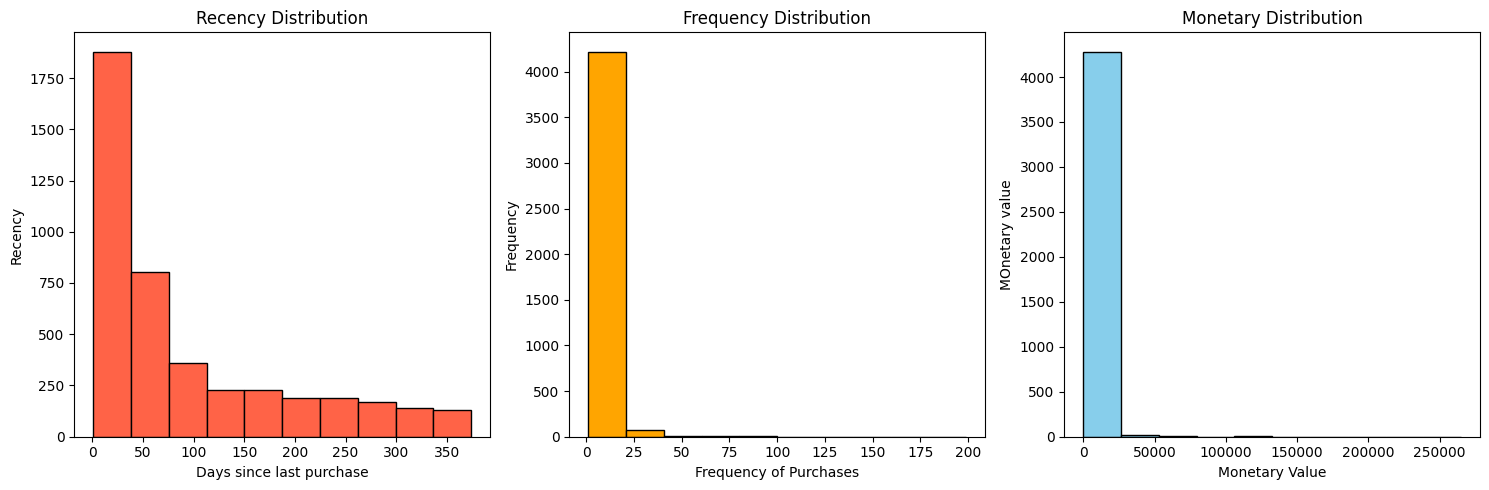

In [35]:
# Check the distribution of RFM values
# %pip install matplotlib
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.hist(customer_rfm['Recency'], bins=10, color='tomato', edgecolor='black')
plt.title('Recency Distribution')
plt.xlabel('Days since last purchase')
plt.ylabel('Recency')

plt.subplot(1, 3, 2)
plt.hist(customer_rfm['Frequency'], bins=10, color='orange', edgecolor='black')
plt.title('Frequency Distribution')
plt.xlabel('Frequency of Purchases')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
plt.hist(customer_rfm['MonetaryValue'], bins=10, color='skyblue', edgecolor='black')
plt.title('Monetary Distribution')
plt.xlabel('Monetary Value')
plt.ylabel('MOnetary value')

plt.tight_layout()
plt.show()

- Recency seems to have a resonable distribution.
- Frequency and Monetary have most of the distribution is towards 0.

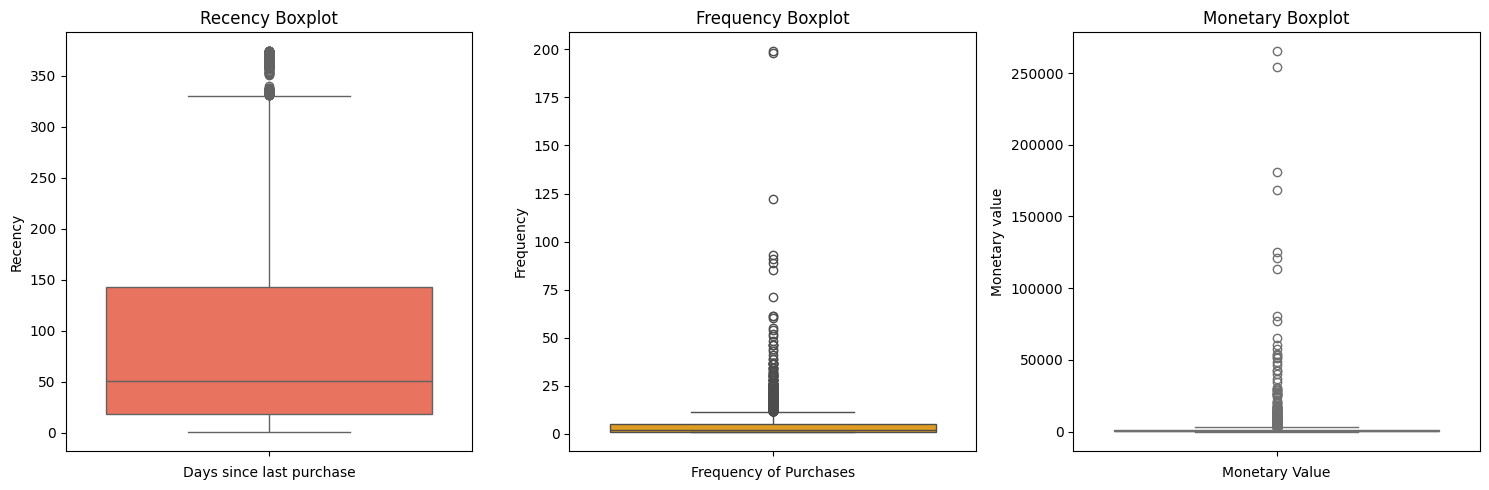

In [36]:
# Check for the outliers
import seaborn as sns

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.boxplot(customer_rfm['Recency'], color='tomato')
plt.title('Recency Boxplot')
plt.xlabel('Days since last purchase')
plt.ylabel('Recency')

plt.subplot(1, 3, 2)
sns.boxplot(customer_rfm['Frequency'], color='orange')
plt.title('Frequency Boxplot')
plt.xlabel('Frequency of Purchases')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
sns.boxplot(customer_rfm['MonetaryValue'], color='skyblue')
plt.title('Monetary Boxplot')
plt.xlabel('Monetary Value')
plt.ylabel('Monetary value')

plt.tight_layout()
plt.show()

- Recency have few outliers.
- Whereas, Frequency and Monetary have huge number of outliers

We can remove them but there will be data loss, these data points are also important to understand the customers in the analysis.

In [37]:
Monetary_Q1 = customer_rfm['MonetaryValue'].quantile(0.25)
Monetary_Q3 = customer_rfm['MonetaryValue'].quantile(0.75)
Monetary_IQR = Monetary_Q3 - Monetary_Q1
Monetary_outliers = customer_rfm[(customer_rfm['MonetaryValue'] > (Monetary_Q3+1.5*Monetary_IQR)) | (customer_rfm['MonetaryValue'] < (Monetary_Q1-1.5*Monetary_IQR))]
Monetary_outliers.describe()

,CustomerID,Recency,Frequency,MonetaryValue
count,415.000000,415.000000,415.000000,415.000000
mean,15058.756627,23.744578,16.638554,11713.042602
std,1805.395901,44.180595,18.901332,25034.610798
min,12346.000000,1.000000,1.000000,3346.000000
25%,13360.500000,3.500000,8.000000,4048.235000
50%,15032.000000,10.000000,12.000000,5392.650000
75%,16678.000000,24.000000,19.000000,8720.120000
max,18251.000000,372.000000,199.000000,265106.920000


In [38]:
Freq_Q1 = customer_rfm['Frequency'].quantile(0.25)
Freq_Q3 = customer_rfm['Frequency'].quantile(0.75)
Freq_IQR = Freq_Q3 - Freq_Q1
Freq_outliers = customer_rfm[(customer_rfm['Frequency'] > (Freq_Q3+1.5*Freq_IQR)) | (customer_rfm['Frequency'] < (Freq_Q1-1.5*Freq_IQR))]
Freq_outliers.describe()

,CustomerID,Recency,Frequency,MonetaryValue
count,274.000000,274.000000,274.000000,274.000000
mean,15361.540146,13.945255,23.007299,13392.313759
std,1754.293469,30.608013,20.852876,28642.587282
min,12395.000000,1.000000,12.000000,1128.440000
25%,13880.250000,3.000000,13.000000,3939.572500
50%,15290.500000,6.000000,17.000000,5933.695000
75%,16806.000000,15.750000,25.000000,10522.685000
max,18283.000000,372.000000,199.000000,265106.920000


`Insight`: Some of the `MonetaryValue` outliers might be `Frequency` outliers. Which means someone buying frequently are probably spending more.

In [39]:
customer_rfm_filtered = customer_rfm[
    (~customer_rfm['MonetaryValue'].isin(Monetary_outliers['MonetaryValue'])) &
    (~customer_rfm['Frequency'].isin(Freq_outliers['Frequency']))
]

customer_rfm_filtered.describe()

,CustomerID,Recency,Frequency,MonetaryValue
count,3848.000000,3848.000000,3848.000000,3848.00000
mean,15315.410603,101.265852,2.745842,787.06556
std,1707.587165,102.082100,2.157524,739.26597
min,12348.000000,1.000000,1.000000,4.25000
25%,13844.750000,22.750000,1.000000,243.44500
50%,15321.500000,59.000000,2.000000,521.22500
75%,16785.000000,162.000000,4.000000,1104.28000
max,18287.000000,374.000000,11.000000,3327.53000


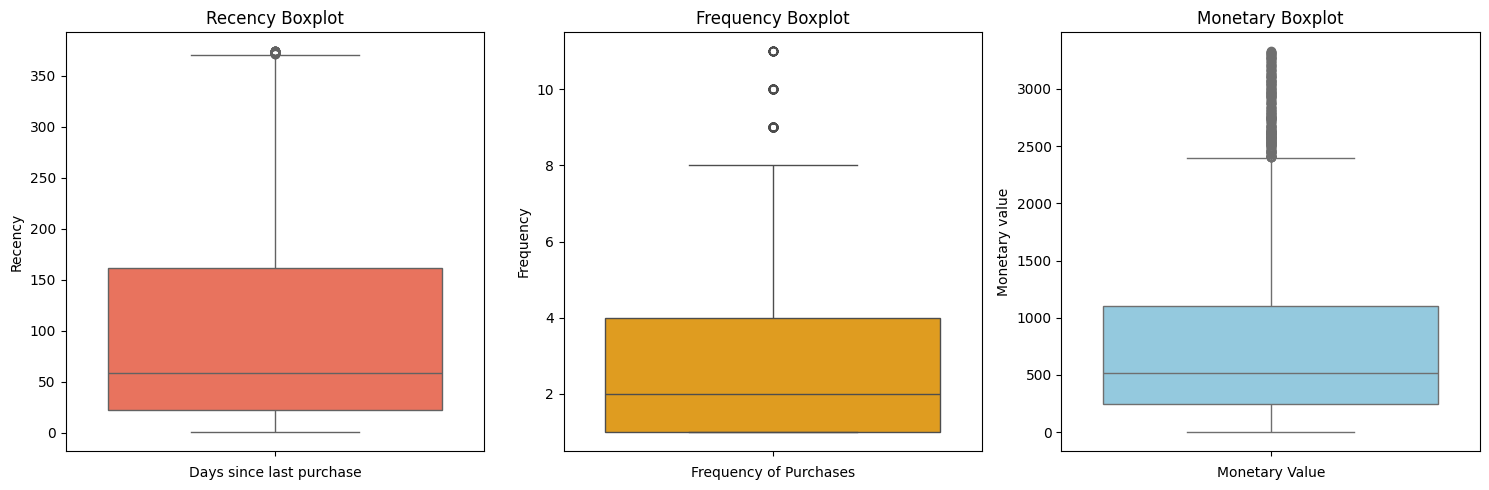

In [40]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.boxplot(customer_rfm_filtered['Recency'], color='tomato')
plt.title('Recency Boxplot')
plt.xlabel('Days since last purchase')
plt.ylabel('Recency')

plt.subplot(1, 3, 2)
sns.boxplot(customer_rfm_filtered['Frequency'], color='orange')
plt.title('Frequency Boxplot')
plt.xlabel('Frequency of Purchases')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
sns.boxplot(customer_rfm_filtered['MonetaryValue'], color='skyblue')
plt.title('Monetary Boxplot')
plt.xlabel('Monetary Value')
plt.ylabel('Monetary value')

plt.tight_layout()
plt.show()

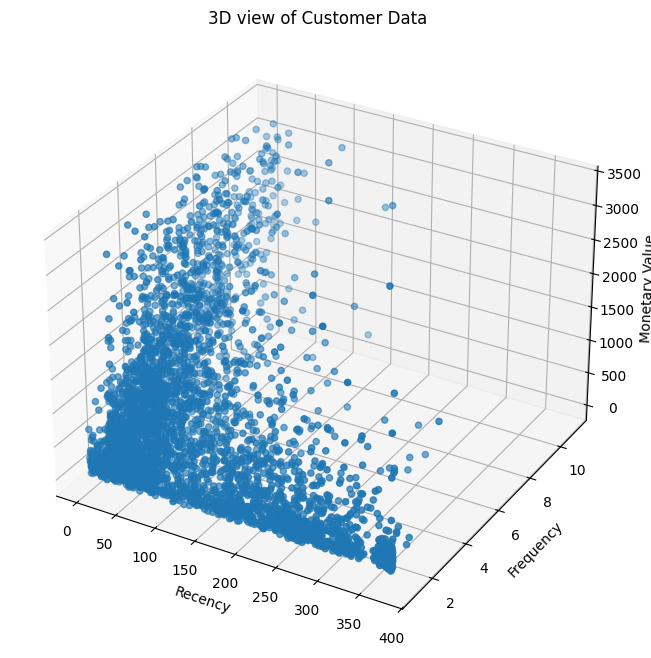

In [41]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection="3d")

ax.scatter(
    customer_rfm_filtered['Recency'],
    customer_rfm_filtered['Frequency'],
    customer_rfm_filtered['MonetaryValue']
)
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary Value')

ax.set_title('3D view of Customer Data')
plt.show()

### Customer Segmentation (Clustering)

As these three features have difference scales clustering using `KMeans` algorithms is sensotive to different scale data. Hence, these need to be standardized.

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

data_scaled = scaler.fit_transform(customer_rfm_filtered[['Recency', 'Frequency', 'MonetaryValue']])
data_scaled

array([[-0.25733469,  0.58137066,  0.8796008 ],
       [-0.80598405, -0.80929302,  0.79190784],
       [ 2.04503312, -0.80929302, -0.71575636],
       ...,
       [ 0.78118015, -0.80929302, -0.95545768],
       [-0.91375445, -0.34573846, -0.82391823],
       [-0.57084861,  0.1178161 ,  0.58578473]], shape=(3848, 3))

In [43]:
data_scaled_df = pd.DataFrame(data_scaled, 
                              columns=['Recency', 'Frequency', 'MonetaryValue'], 
                              index=customer_rfm_filtered.index)
data_scaled_df

,Recency,Frequency,MonetaryValue
2,-0.257335,0.581371,0.879601
3,-0.805984,-0.809293,0.791908
4,2.045033,-0.809293,-0.715756
5,-0.639430,1.972034,0.793017
6,1.006518,-0.809293,-0.944391
...,...,...,...
4308,-0.267132,-0.809293,-0.829533
4309,1.731519,-0.809293,-0.820468
4310,0.781180,-0.809293,-0.955458
4311,-0.913754,-0.345738,-0.823918


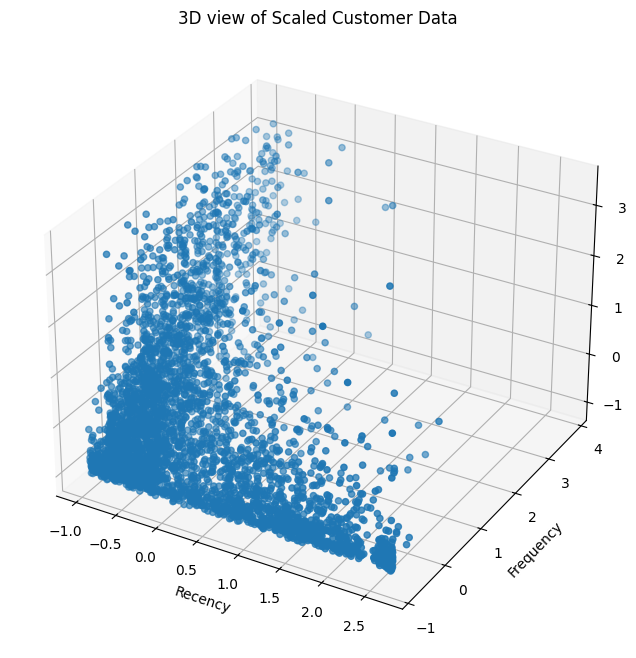

In [44]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection="3d")

ax.scatter(
    data_scaled_df['Recency'],
    data_scaled_df['Frequency'],
    data_scaled_df['MonetaryValue']
)
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary Value')

ax.set_title('3D view of Scaled Customer Data')
plt.show()

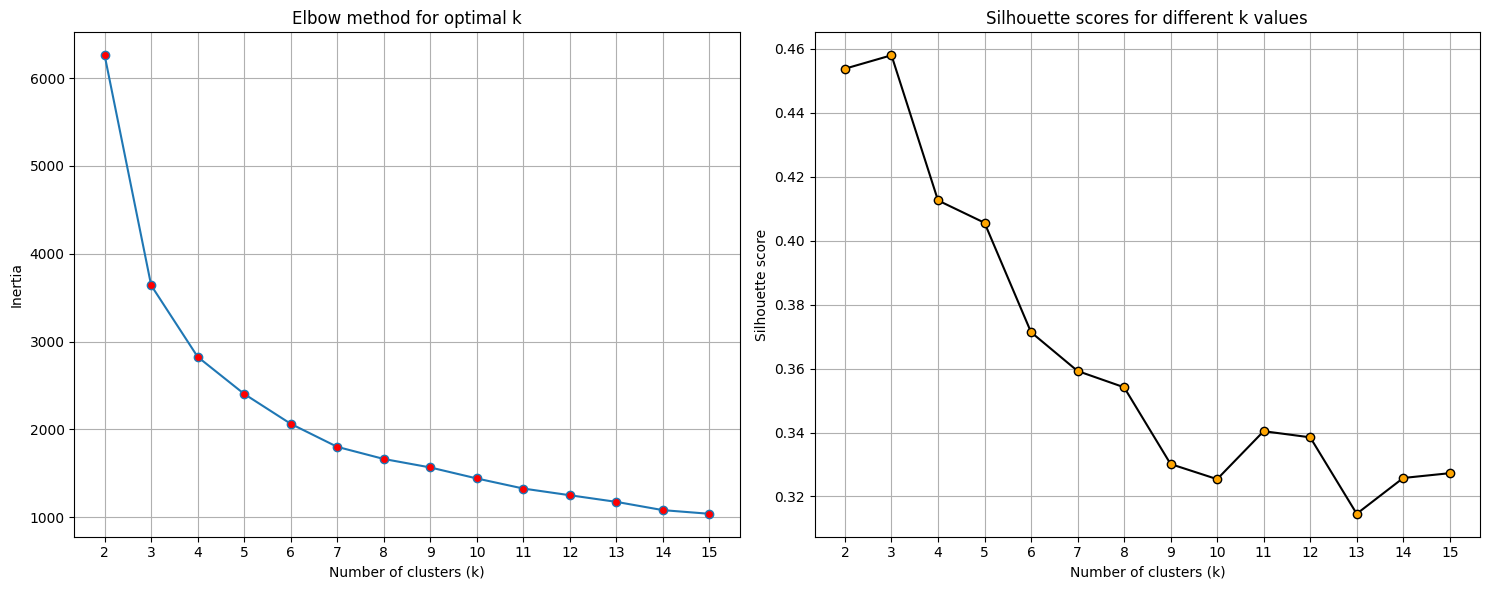

In [45]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

MAX_CLUSTERS = 15
inertia_values = []
silhouette_scores = []
k_values = range(2, MAX_CLUSTERS + 1)

for k in k_values:
    kmeans_model = KMeans(
        n_clusters=k,
        random_state=1,
        max_iter=1000
    )
    clusters = kmeans_model.fit_predict(data_scaled_df)

    sil_score = silhouette_score(data_scaled_df, clusters)

    inertia = kmeans_model.inertia_
    inertia_values.append(inertia)
    silhouette_scores.append(sil_score)

# Plot the inertia values for different k values
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.plot(k_values, inertia_values, marker='o', markerfacecolor='red')
plt.title('Elbow method for optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, color='black', marker='o', markerfacecolor='orange')
plt.title('Silhouette scores for different k values')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette score')
plt.xticks(k_values)
plt.grid()

plt.tight_layout()
plt.show()



`k` values 4 and 5 seems to be better choice. A metrics called `Silhouette score` will help use decide the number of clusters precisely.
- Silhouette score ranges between [-1, 1]
- Higher the score (near to 1) more distinct clusters
- Right plot shows that k=4 has the highest score than k=5

In [46]:
kmeans = KMeans(
    n_clusters = 4,
    random_state = 1,
    max_iter = 1000
)

cluster_labels = kmeans.fit_predict(data_scaled_df)
cluster_labels

array([1, 2, 0, ..., 0, 2, 1], shape=(3848,), dtype=int32)

In [47]:
customer_rfm_filtered['Cluster'] = cluster_labels
customer_rfm_filtered

,CustomerID,Recency,Frequency,MonetaryValue,Cluster
2,12348.0,75,4,1437.24,1
3,12349.0,19,1,1372.42,2
4,12350.0,310,1,258.00,0
5,12352.0,36,7,1373.24,3
6,12353.0,204,1,89.00,0
...,...,...,...,...,...
4308,18278.0,74,1,173.90,2
4309,18280.0,278,1,180.60,0
4310,18281.0,181,1,80.82,0
4311,18282.0,8,2,178.05,2


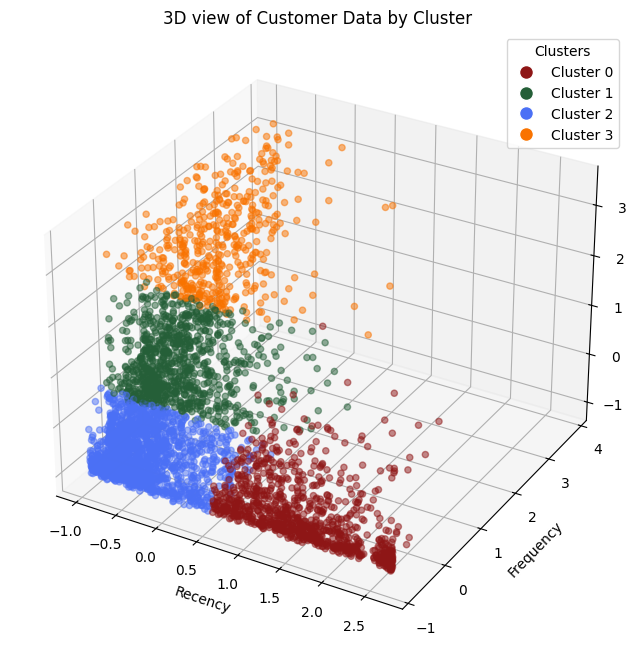

In [48]:
# Visualize the clusters in 3D
cluster_colors = {
    0: '#8E1616',
    1: '#255F38',
    2: '#4B70F5',
    3: '#F97300'
}

colors = customer_rfm_filtered['Cluster'].map(cluster_colors)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection="3d")

ax.scatter(
    data_scaled_df['Recency'],
    data_scaled_df['Frequency'],
    data_scaled_df['MonetaryValue'],
    c=colors,
    alpha=0.5,
    marker='o'
)
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary Value')

ax.set_title('3D view of Customer Data by Cluster')
plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', label=f'Cluster {i}',
                               markerfacecolor=color, markersize=10) for i, color in cluster_colors.items()],
           title='Clusters', loc='upper right')
plt.show()

In [49]:
segment_summary = customer_rfm_filtered.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'MonetaryValue': 'mean'
}).round(2)

print(segment_summary)

         Recency  Frequency  MonetaryValue
Cluster                                   
0         259.64       1.36         343.84
1          48.29       3.93        1153.36
2          56.86       1.61         390.58
3          32.63       6.94        2260.98


K-Means algorithm has successfully separated customers into four distinct groups based on their RFM scores.
- Cluster 3 (Orange): `Champions` customers
    - This group has **very low Recency** (avg. 32 days), **very high Frequency** (avg. 7 purchases), and **high MonetaryValue** (avg. £2,261)
    - This group is the most valuable group.
- Cluster 2 (Blue): `New/Potential` customers
    - This group has **low Recency** (avg. 56 days), but very **low Frequency** (avg. 1.6 purchases) and **low Monetary value** (avg. £390).
    - They could be new customers or occasional shoppers who are promissing. They need to be actively engaged.
- Cluster 1 (Green): `Loyal Customers` customers
    - This group has **low Recency** (avg. 48 days), **good Frequency** (avg. 4 purchases), and **strong Monetary value** (avg. £1,153).
    - These customers are the backbone of the business. They are reliable and have high potential to become Champions.
- Cluster 0 (Dark Red): `At-Risk` customers
    - This group has **extremely high Recency** (avg. 260 days), and the **lowest Frequency** and **lowest Monetary values**.
    - These customers have likely churned. It's been almost 9 months since their last purchase.

## 2. Market Basket Analysis

Understanding which products are purchased together can inform merchandising strategies – for example, cross‑selling complementary items, arranging store or site layout so that frequently co‑purchased goods are close to each other, or designing bundle promotions. These types of insights are the goal of *market basket analysis*.

We will look for patterns of co‑occurrence in transactional data, which is also known as **frequent itemset mining**.

The strength of the relationships is measured using three key metrics:
1. `Support`: the proportion of transactions that contain a particular item or itemset. High support indicates that an itemset is frequent in the dataset.
2. `Confidence`: the conditional probability that a transaction containing the antecedent (left side) also contains the consequent (right side). High confidence suggests that purchasing the antecedent implies a high likelihood of purchasing the consequent.
3. `Lift`: measures how much more often the antecedent and consequent occur together compared with what would be expected if they were independent. It is the ratio of the confidence to the support of the consequent. A lift greater than 1 indicates a positive association; values below 1 mean the items occur together less than expected.

In [50]:
# Build the basket matrix (rows are invoices, columns are items)
basket = (cleaned_data
    .groupby(['InvoiceNo', 'Description'])['Quantity']
    .sum()
    .unstack()
    .fillna(0)
)

basket_sets = basket.applymap(lambda x: 1 if x > 0 else 0)

In [51]:
# Generate frequent itemsets and association rules
from mlxtend.frequent_patterns import apriori, association_rules

def apriori_analysis(basket_data, min_support= 0.01, min_threshold = 1, max_items=3):
    frequent_itemsets = apriori(basket_data, min_support=min_support, use_colnames=True, max_len=max_items)

    rules = association_rules(frequent_itemsets, metric='lift', min_threshold=min_threshold)
    rules = rules[rules['confidence'] >= 0.5]
    rules = rules.sort_values(by='lift', ascending=False)
    
    return frequent_itemsets, rules

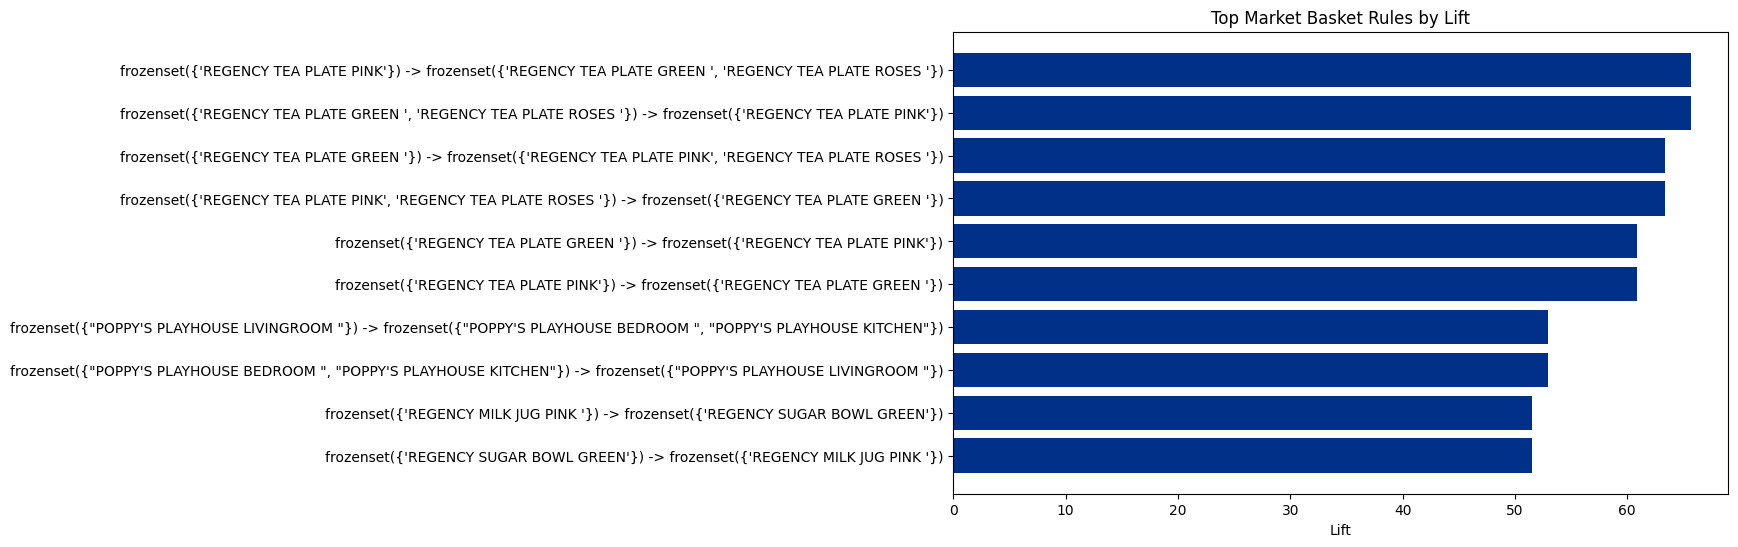

In [ ]:
# Run the apriori analysis
frequent_itemsets, rules = apriori_analysis(
    basket_sets,
    min_support=0.01,
    min_threshold=1,
    max_items=3
)

# Visualize the results
import matplotlib.pyplot as plt

# Select top 10 rules by lift
top_rules = rules.head(10)

plt.figure(figsize=(10, 6))
plt.barh(range(len(top_rules)), top_rules['lift'], color='#003087')
plt.yticks(range(len(top_rules)), [f"{row['antecedents']} -> {row['consequents']}" 
                                   for _, row in top_rules.iterrows()])
plt.xlabel('Lift')
plt.title('Top Market Basket Rules by Lift')
plt.gca().invert_yaxis()
plt.show()

`Insights`:
1. The highest‑lift rules involve different colour variants of the same “`Regency Tea Plate`”.
    * When customers buy both the `Regency Tea Plate Green` and `Regency Tea Plate Roses` together, they almost always add the `Regency Tea Plate Pink` to their basket. 
    * The lift values around 60 mean this combination occurs about sixty times more often than you would expect if people picked these items independently.
    * In other words, shoppers treat the three colour variations as part of a matching set.
    * The pattern repeats when you look at two‑item antecedents: people who buy the `Regency Tea Plate Green` almost always also buy the `Regency Tea Plate Pink`, and vice versa.
    * This suggests very strong relation within the Regency Tea Plate range and highlights an opportunity to bundle or promote these variants together.
2. Another cluster appears around Poppy’s Playhouse toy sets.
    * Transactions containing both the `Poppy's Playhouse Kitchen` and the `Poppy's Playhouse Bedroom` almost always include the `Poppy's Playhouse Livingroom`.
    * Similarly, purchasing either the kitchen or bedroom sets greatly increases the likelihood of buying the living room set.
    * These rules suggest a logical progression: once parents start buying individual playhouse rooms, they tend to complete the collection.
3. The last pair of rules ties the `Regency sugar bowl` and `milk jug` together.
    * Customers who buy the `pink milk jug` frequently add the `green sugar bowl`, and the reverse is also true.
    * Lift values above 50 indicate a very strong association - again, people seem to favour matching items from the same product line.

Generating rules with minimum support: 0.01 and max itemsets: 2


/Users/neehanth/Documents/Masters/Data Mining/E-commerce Customer Analytics/project_env/lib/python3.12/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Number of frequent itemsets: 851
Number of rules generated: 122
Time taken: 17.90 seconds


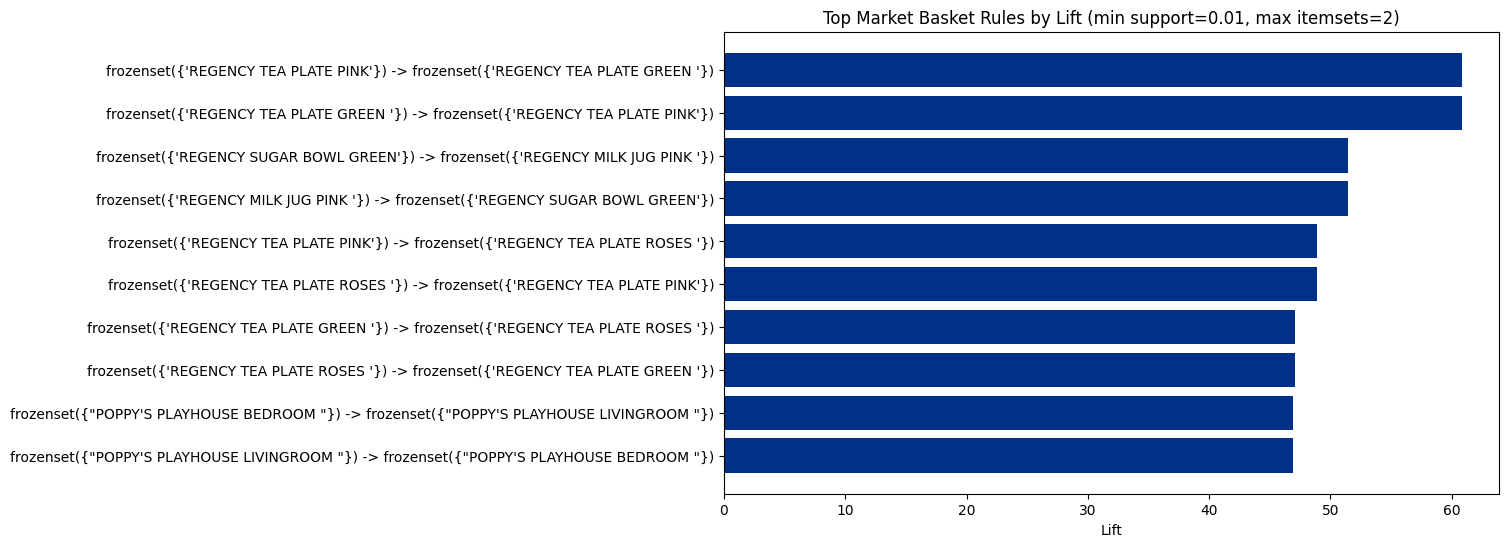

Generating rules with minimum support: 0.01 and max itemsets: 3


/Users/neehanth/Documents/Masters/Data Mining/E-commerce Customer Analytics/project_env/lib/python3.12/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Number of frequent itemsets: 901
Number of rules generated: 251
Time taken: 18.91 seconds


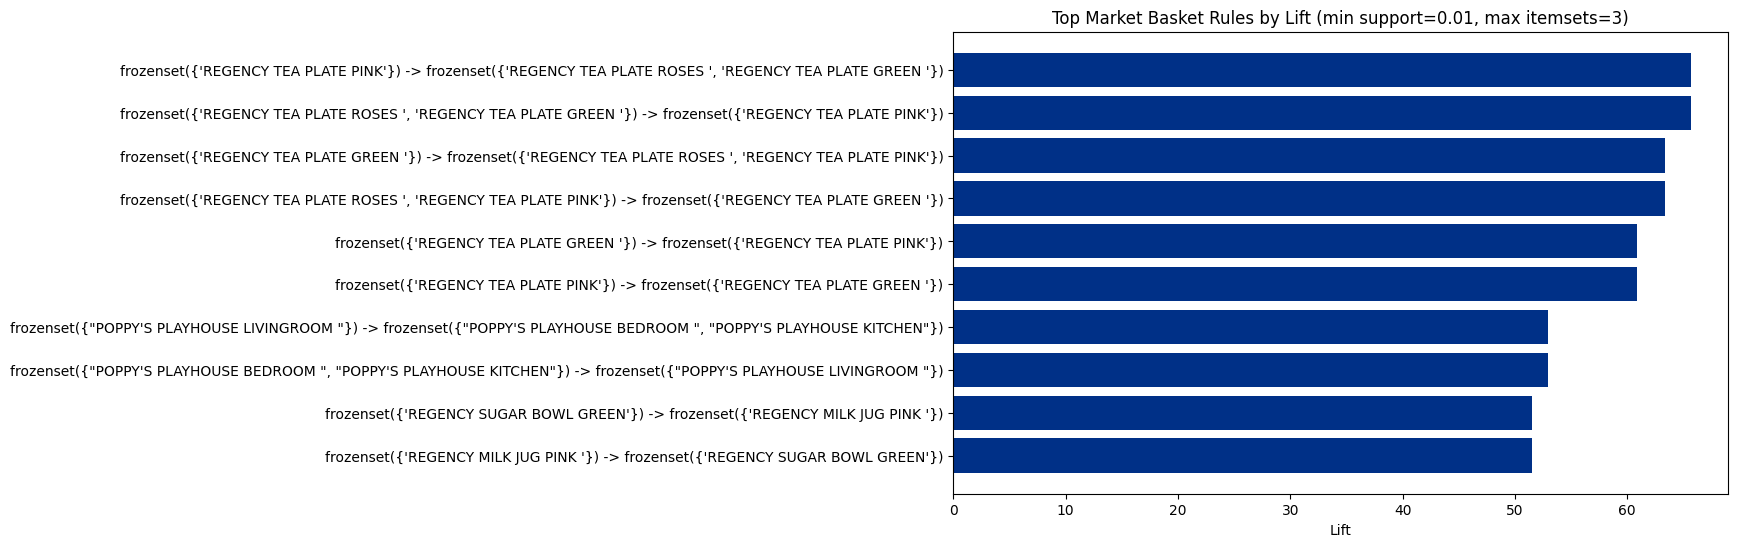

Generating rules with minimum support: 0.01 and max itemsets: 4


/Users/neehanth/Documents/Masters/Data Mining/E-commerce Customer Analytics/project_env/lib/python3.12/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Number of frequent itemsets: 903
Number of rules generated: 264
Time taken: 18.55 seconds


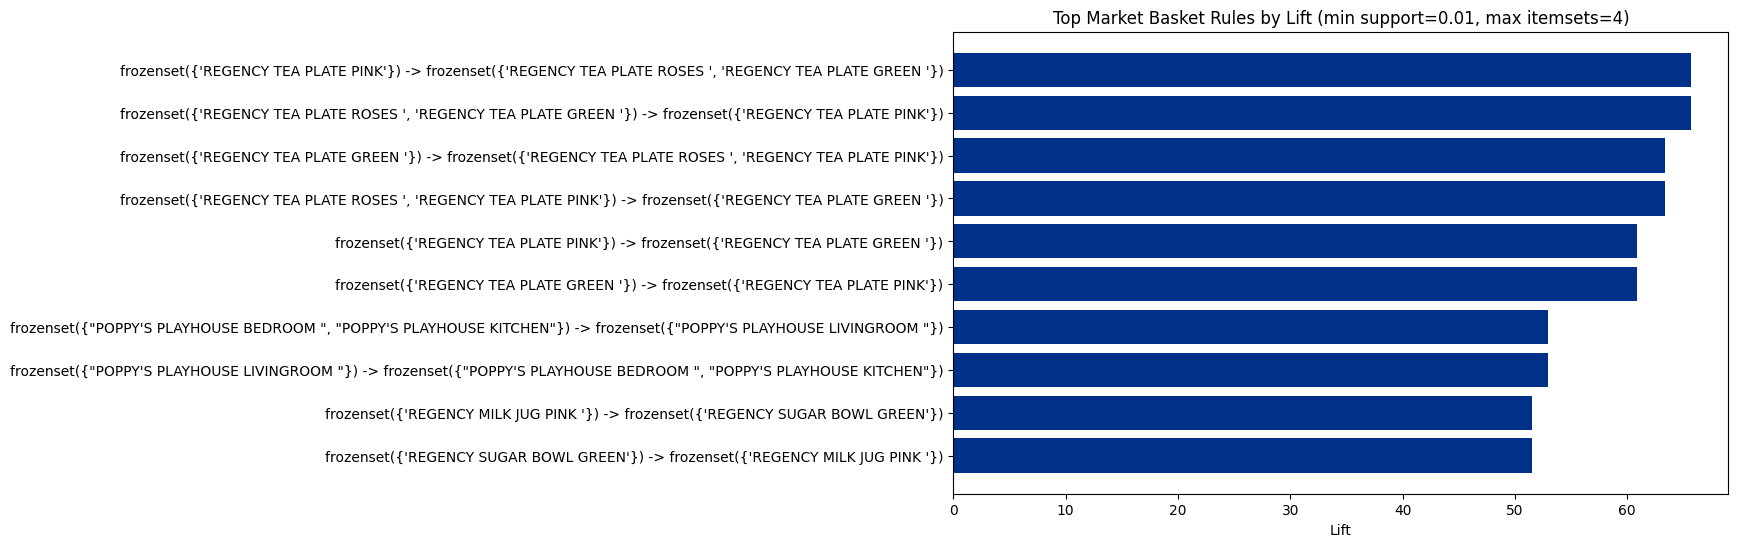

Generating rules with minimum support: 0.02 and max itemsets: 2


/Users/neehanth/Documents/Masters/Data Mining/E-commerce Customer Analytics/project_env/lib/python3.12/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Number of frequent itemsets: 232
Number of rules generated: 20
Time taken: 1.22 seconds


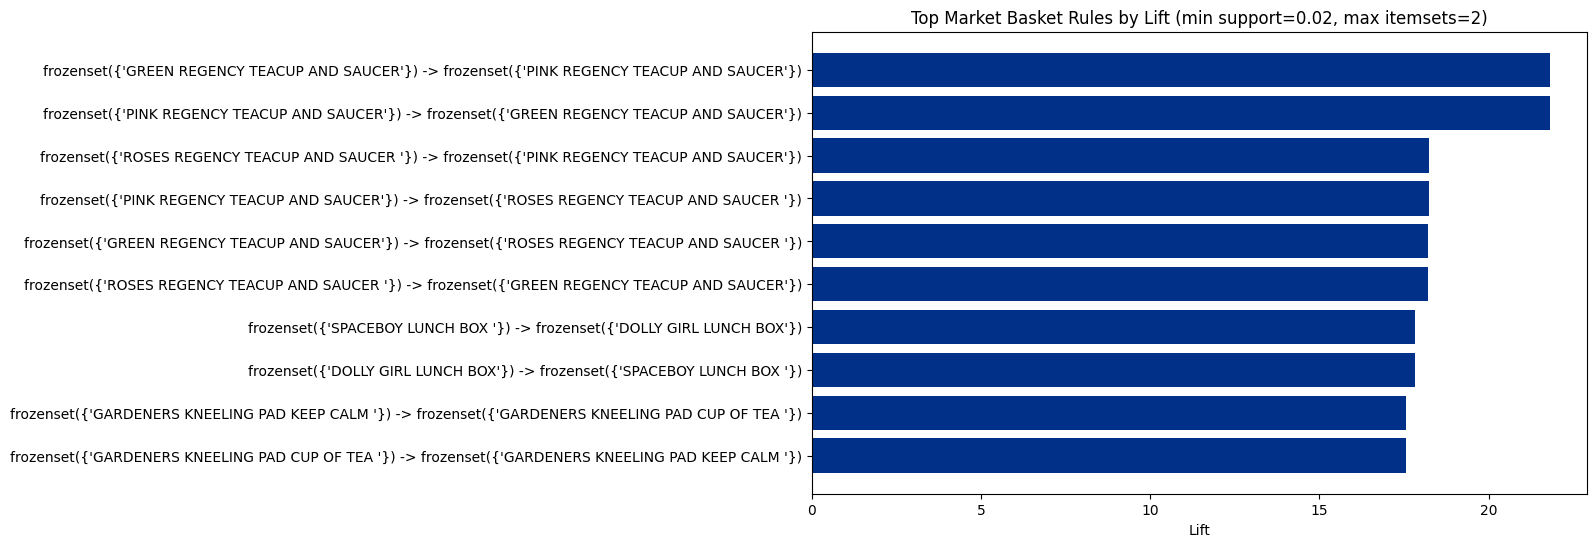

Generating rules with minimum support: 0.02 and max itemsets: 3


/Users/neehanth/Documents/Masters/Data Mining/E-commerce Customer Analytics/project_env/lib/python3.12/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Number of frequent itemsets: 233
Number of rules generated: 25
Time taken: 1.22 seconds


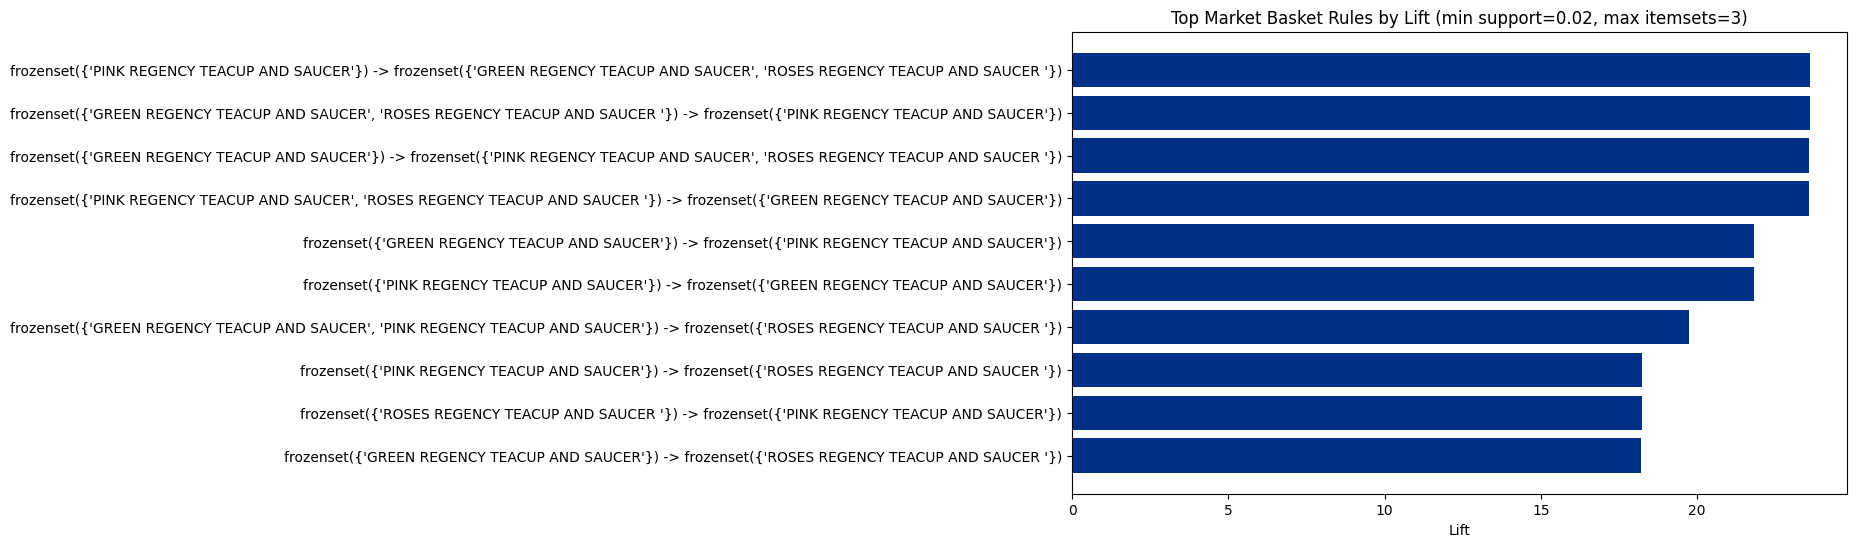

Generating rules with minimum support: 0.02 and max itemsets: 4


/Users/neehanth/Documents/Masters/Data Mining/E-commerce Customer Analytics/project_env/lib/python3.12/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Number of frequent itemsets: 233
Number of rules generated: 25
Time taken: 1.16 seconds


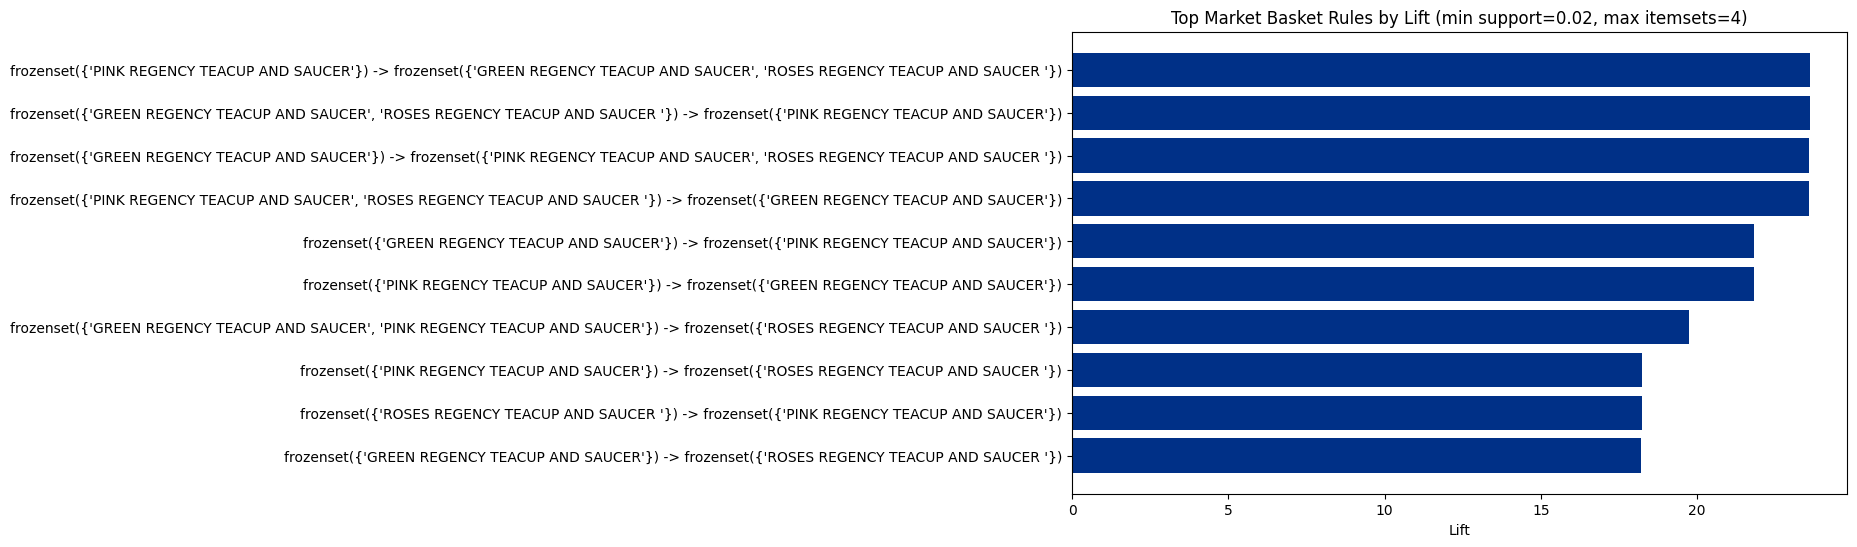

Generating rules with minimum support: 0.03 and max itemsets: 2


/Users/neehanth/Documents/Masters/Data Mining/E-commerce Customer Analytics/project_env/lib/python3.12/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Number of frequent itemsets: 87
Number of rules generated: 0
Time taken: 0.28 seconds


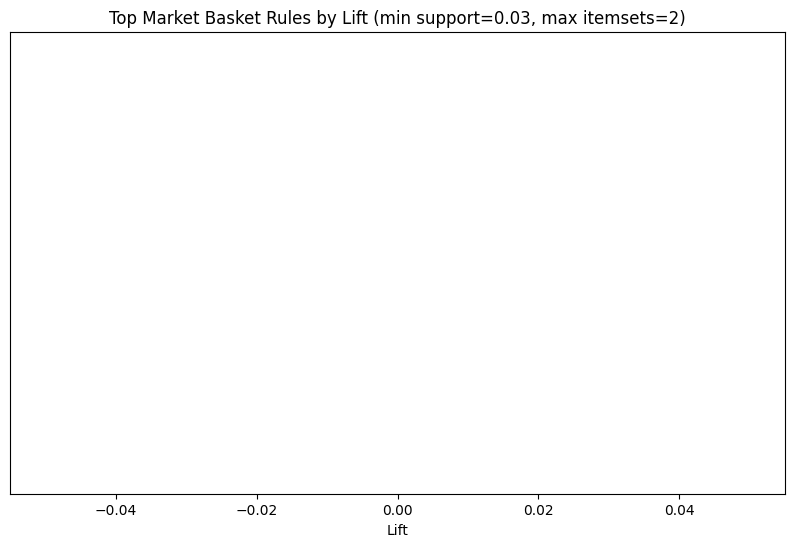

Generating rules with minimum support: 0.03 and max itemsets: 3


/Users/neehanth/Documents/Masters/Data Mining/E-commerce Customer Analytics/project_env/lib/python3.12/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Number of frequent itemsets: 87
Number of rules generated: 0
Time taken: 0.28 seconds


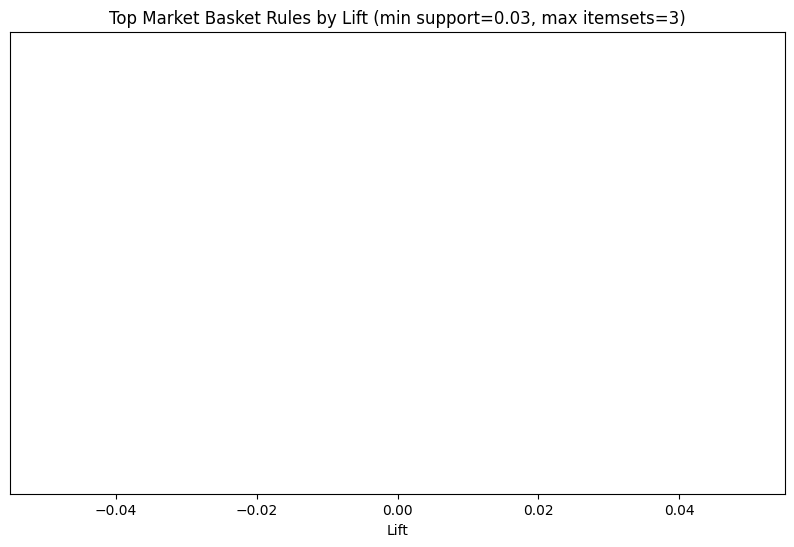

Generating rules with minimum support: 0.03 and max itemsets: 4


/Users/neehanth/Documents/Masters/Data Mining/E-commerce Customer Analytics/project_env/lib/python3.12/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Number of frequent itemsets: 87
Number of rules generated: 0
Time taken: 0.29 seconds


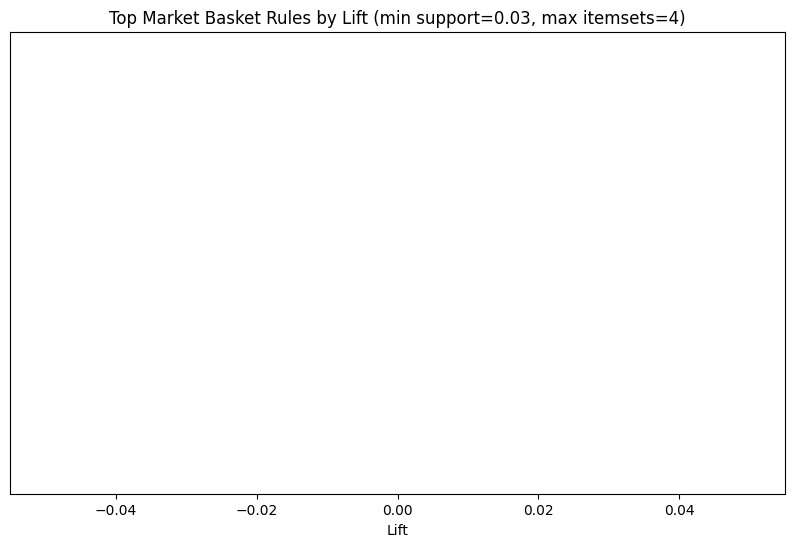

In [52]:
import time

for min_sup in [0.01, 0.02, 0.03]:
    for max_item_sets in [2, 3, 4]:
        print(f"Generating rules with minimum support: {min_sup} and max itemsets: {max_item_sets}")
        
        start_time = time.time()
        frequent_itemsets, rules = apriori_analysis(
            basket_sets,
            min_support=min_sup,
            min_threshold=1,
            max_items=max_item_sets
        )
        total_time = time.time() - start_time
        print(f"Number of frequent itemsets: {len(frequent_itemsets)}")
        print(f"Number of rules generated: {len(rules)}")
        print(f"Time taken: {total_time:.2f} seconds")
        
        top_rules = rules.head(10)

        plt.figure(figsize=(10, 6))
        plt.barh(range(len(top_rules)), top_rules['lift'], color='#003087')
        plt.yticks(range(len(top_rules)), [f"{row['antecedents']} -> {row['consequents']}" 
                                        for _, row in top_rules.iterrows()])
        plt.xlabel('Lift')
        plt.title(f'Top Market Basket Rules by Lift (min support={min_sup}, max itemsets={max_item_sets})')
        plt.gca().invert_yaxis()
        plt.show()

`Overview`:
The Apriori algorithm was run on the one‑hot encoded basket matrix using a range of minimum support thresholds and maximum itemset lengths.

`Results`:
| `min_support` | Max itemset length | Frequent itemsets | Rules generated | Runtime (sec) | Observations                                                                                                         |
| ------------- | ------------------ | ----------------- | --------------- | ------------- | -------------------------------------------------------------------------------------------------------------------- |
| **0.01**      | 2                  | 851               | 122             | 17.90         | Many frequent itemsets and rules; top rules involve *Regency Tea Plate* colour variants and toy room sets.           |
| **0.01**      | 3                  | 901               | 251             | 18.91         | Allowing three‑item sets increases the rule count; new rules combine three variants (e.g., pink + roses ⇒ green).    |
| **0.01**      | 4                  | 903               | 264             | 18.55         | Little change beyond three items, suggesting most frequent sets have ≤3 items.                                       |
| **0.02**      | 2                  | 232               | 20              | 1.22          | Raising support sharply reduces itemsets and rules; strongest rules now involve *Regency Teacup and Saucer* colours. |
| **0.02**      | 3                  | 233               | 25              | 1.22          | Three‑item rules emerge but are variants of the same teacup combinations.                                            |
| **0.02**      | 4                  | 233               | 25              | 1.16          | No additional multi‑item patterns beyond size 3.                                                                     |
| **0.03**      | 2                  | 87                | 0               | 0.28          | At 3 % support no rules meet the lift threshold; frequent itemsets exist but they are not predictive.                |
| **0.03**      | 3                  | 87                | 0               | 0.28          | Same as above.                                                                                                       |
| **0.03**      | 4                  | 87                | 0               | 0.29          | Same as above.                                                                                                       |

`Insights`:
* **With 1 % support, max‑itemset = 3**
    - Shoppers who buy Regency Tea Plate Green and Regency Tea Plate Roses, they almost always add the Regency Tea Plate Pink; similarly, purchasing any one colour of the Regency plates strongly predicts adding the other two.
    - Another cluster shows parents completing the Poppy’s Playhouse toy collection - buying the bedroom and kitchen sets together.
    - These high‑lift (>60) associations are rare but very strong.
* **With 2 % support, max‑itemset = 3**
    - The strongest rules now revolve around the Regency Teacup and Saucer line: customers who buy one colour (e.g. pink) often pick up the other colours (green and roses) in the same order. The lift values are lower (around 20) because these products are popular, but the patterns are still meaningful.
    - A few other pairings emerge, such as Spaceboy and Dolly Girl lunch boxes or different Gardeners Kneeling Pad designs, suggesting complementary or substitute products within these categories.

`Recommendations`:
1. **Bundle and promote complementary items**: The high-lift combinations - such as customers buying all three Regency Tea Plate colours together or completing Poppy’s Playhouse room sets - lend themselves to multi‑item discounts and “complete the set” promotions.
    - Client could offer a discounted trio of pink, green and roses tea plates or a bundled price for all three Poppy’s Playhouse rooms.
2. **Optimize product placement and recommendations**: Place the strongly associated items adjacent to each other on shelves or group them together on the product detail page.
    - Online, incorporate “Complete your tea set with…” or “People also bought…” recommendations.
3. **Coordinate inventory and stocking** Because these products drive each other’s demand, ensure that complementary items are in stock together. Knowing which items boost each other’s sales helps retailers forecast inventory more accurately and avoid out‑of‑stock situations.